<a href="https://colab.research.google.com/github/leonardo2004/Calculo-Numerico/blob/main/Atividade_01/Atividade01_CalcNumerico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade 01 - Calculo Numérico
## Leonardo Tomasela Leal - RA: 170291
## Giovanna Maria de Siqueira Junqueira - RA: 185218

In [97]:
import math
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Parte A


,Valor,n,Método,Aproximação,Ea,Er,E% (%)
0,x1,0,Arredondamento,3.000000,0.141593,0.045070,4.507034
1,x1,0,Truncamento,3.000000,0.141593,0.045070,4.507034
2,x1,1,Arredondamento,3.100000,0.041593,0.013239,1.323935
3,x1,1,Truncamento,3.100000,0.041593,0.013239,1.323935
4,x1,2,Arredondamento,3.140000,0.001593,0.000507,0.050696
5,x1,2,Truncamento,3.140000,0.001593,0.000507,0.050696
6,x1,3,Arredondamento,3.142000,0.000407,0.000130,0.012966
7,x1,3,Truncamento,3.141000,0.000593,0.000189,0.018865
8,x1,4,Arredondamento,3.141600,0.000007,0.000002,0.000234
9,x1,4,Truncamento,3.141500,0.000093,0.000029,0.002949


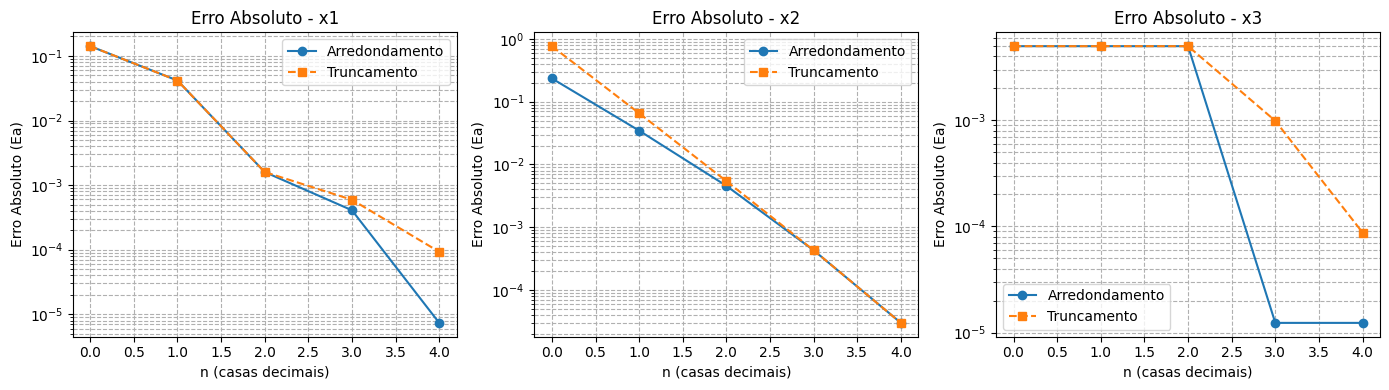

In [98]:
def truncar(x, n):
    return math.trunc(x * (10 ** n)) / (10 ** n)

# Valores de referência fornecidos
valores = {
    "x1": 3.14159265,
    "x2": 98.76543,
    "x3": 0.00498765
}

resultados = []

# Calculando aproximações e erros para n de 0 a 4
for nome, x in valores.items():
    for n in range(5):
        # 1. Arredondamento
        x_arr = round(x, n)
        ea_arr = abs(x - x_arr)
        er_arr = ea_arr / abs(x) if x != 0 else 0
        ep_arr = er_arr * 100

        resultados.append({
            "Valor": nome, "n": n, "Método": "Arredondamento",
            "Aproximação": x_arr, "Ea": ea_arr, "Er": er_arr, "E% (%)": ep_arr
        })

        # 2. Truncamento
        x_tr = truncar(x, n)
        ea_tr = abs(x - x_tr)
        er_tr = ea_tr / abs(x) if x != 0 else 0
        ep_tr = er_tr * 100

        resultados.append({
            "Valor": nome, "n": n, "Método": "Truncamento",
            "Aproximação": x_tr, "Ea": ea_tr, "Er": er_tr, "E% (%)": ep_tr
        })

# Criação da tabela
df = pd.DataFrame(resultados)
pd.set_option('display.float_format', lambda x: '%.6f' % x)
display(df)

# Gerando os gráfico em escala logarítmica de Ea em função de n
plt.figure(figsize=(14, 4))

for i, nome in enumerate(["x1", "x2", "x3"]):
    plt.subplot(1, 3, i + 1)
    df_val = df[df["Valor"] == nome]

    # Linha para Arredondamento
    arr = df_val[df_val["Método"] == "Arredondamento"]
    plt.plot(arr["n"], arr["Ea"], marker='o', label='Arredondamento')

    # Linha para Truncamento
    tr = df_val[df_val["Método"] == "Truncamento"]
    plt.plot(tr["n"], tr["Ea"], marker='s', linestyle='--', label='Truncamento')

    plt.yscale('log')
    plt.xlabel('n (casas decimais)')
    plt.ylabel('Erro Absoluto (Ea)')
    plt.title(f'Erro Absoluto - {nome}')
    plt.grid(True, which="both", ls="--")
    plt.legend()

plt.tight_layout()
plt.show()

# Parte B
## 1)

raw : [121.7 120.4 122.1 119.8 121.2 120.9 122.4 121.  120.2 121.5]
média: 121.12
min: 119.8
max: 122.4
amplitude 2.600000e+00
desvio 7.909488e-01

Erro absoluto = 0.000000e+00
Erro relativo = 0.000000e+00
Erro percentual = 0.000000e+00

round_0 : [122. 120. 122. 120. 121. 121. 122. 121. 120. 122.]
média: 121.1
min: 120.0
max: 122.0
amplitude 2.000000e+00
desvio 8.306624e-01

Erro absoluto = 2.000000e-02
Erro relativo = 1.651255e-04
Erro percentual = 1.651255e-02

trunc : [121. 120. 122. 119. 121. 120. 122. 121. 120. 121.]
média: 120.7
min: 119.0
max: 122.0
amplitude 3.000000e+00
desvio 9.000000e-01

Erro absoluto = 4.200000e-01
Erro relativo = 3.467635e-03
Erro percentual = 3.467635e-01



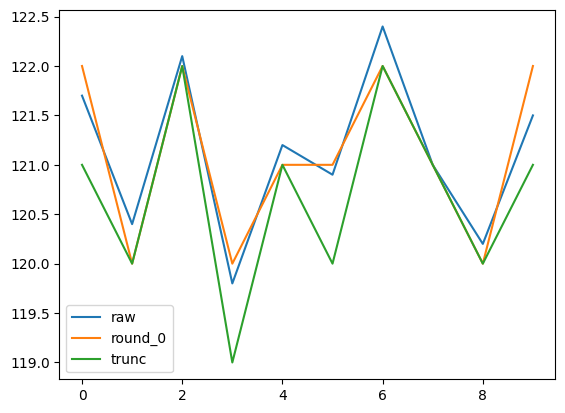

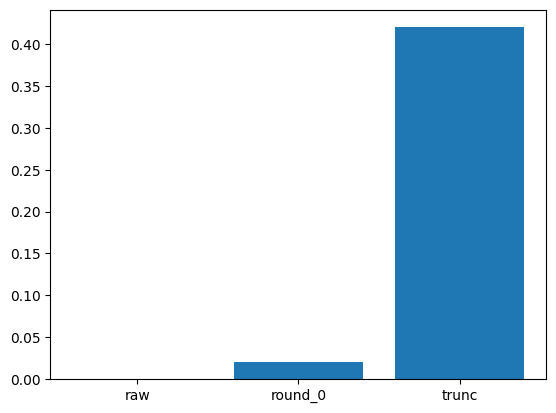

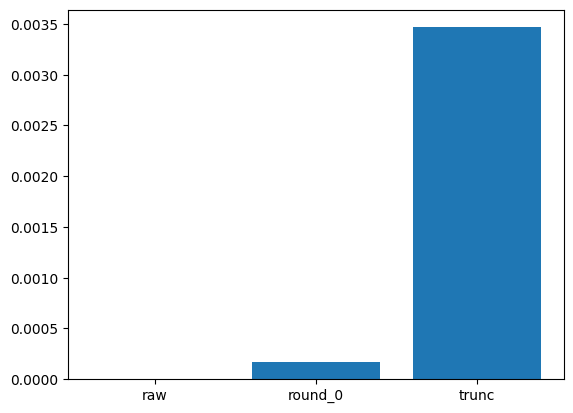

(array([1., 0., 0., 3., 0., 0., 4., 0., 0., 2.]),
 array([119. , 119.3, 119.6, 119.9, 120.2, 120.5, 120.8, 121.1, 121.4,
        121.7, 122. ]),
 <BarContainer object of 10 artists>)

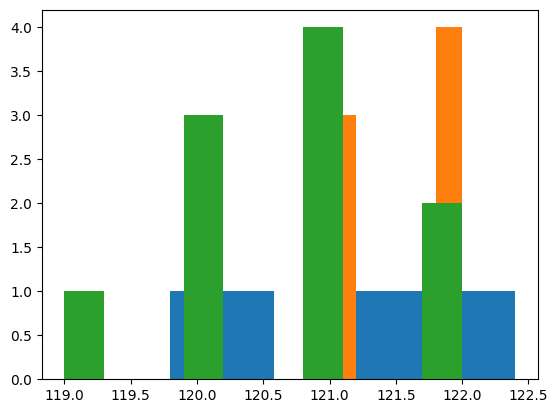

In [99]:
pressao = {
    "raw" : np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]),
    "round_0" : np.round(pressao["raw"],0),
    "trunc" : np.trunc(pressao["raw"]),
}

pressao_mean = {}
abs_error = {}
rel_error = {}
per_error = {}
for item, lista in pressao.items():
  pressao_mean[item] = lista.mean()
  print(f"{item} : {lista}\n"
  f"média: {pressao_mean[item]}\n"
  f"min: {lista.min()}\n"
  f"max: {lista.max()}\n"
  f"amplitude {lista.max()-lista.min():e}\n"
  f"desvio {lista.std():e}\n")
  abs_error[item] = abs(pressao_mean["raw"]-pressao_mean[item])
  rel_error[item] = abs_error[item]/pressao_mean["raw"]
  per_error[item] = 100*rel_error[item]
  print(f"Erro absoluto = {abs_error[item]:e}\n"
  f"Erro relativo = {rel_error[item]:e}\n"
  f"Erro percentual = {per_error[item]:e}\n")

x = np.arange(10)
for item, lista in pressao.items():
  plt.plot(x,lista, label=item)
  plt.legend()
plt.show()


plt.bar(abs_error.keys(),abs_error.values())

plt.show()

plt.bar(rel_error.keys(),rel_error.values())

plt.show()

x,y = np.histogram(pressao['raw'])

plt.hist(y[:-1],y, weights=x)

x,y = np.histogram(pressao['round_0'])

plt.hist(y[:-1],y, weights=x)


x,y = np.histogram(pressao['trunc'])

plt.hist(y[:-1],y, weights=x)

# 2)

## Parte C


# 1)


In [100]:
def truncar(x, n):
    return math.trunc(x * (10 ** n)) / (10 ** n)

def arredondar_centenas(valores):
  return round(valores, -2)

def truncar_centenas(valores):
  return np.trunc(valores / 100) * 100

def calcula_Q(r, mu, dp, L=0.20):
  r_m = r * 1e-3
  return (np.pi * (r_m ** 4) * dp) / (8 * mu * L)

  # Dados de referência fornecidos
r_orig = 0.80
L_val = 0.20
mu_orig = 3.5e-3
dp_orig = 1200.0

# 1. Q com todos os valores exatos (base)
Q_exato = calcula_Q(r_orig, mu_orig, dp_orig, L_val)

# - r arredondado e truncado para 1 casa decimal em mm
r_arr = round(r_orig, 1)
r_tru = truncar(r_orig, 1)

# - mu arredondada e truncada para 3 casas decimais em Pa s
mu_arr = round(mu_orig, 3)
mu_tru = truncar(mu_orig, 3)

# - dp arredondada e truncada para centenas de pascal
dp_arr = arredondar_centenas(dp_orig)
dp_tru = truncar_centenas(dp_orig)

# Cenários solicitados (2, 3, 4 e 5)
cenarios = [
    {"Cenário": "1. Todos originais", "r": r_orig, "mu": mu_orig, "dp": dp_orig},
    {"Cenário": "2. r arredondado (1 casa)", "r": r_arr, "mu": mu_orig, "dp": dp_orig},
    {"Cenário": "2. r truncado (1 casa)", "r": r_tru, "mu": mu_orig, "dp": dp_orig},
    {"Cenário": "3. mu arredondado (3 casas)", "r": r_orig, "mu": mu_arr, "dp": dp_orig},
    {"Cenário": "3. mu truncado (3 casas)", "r": r_orig, "mu": mu_tru, "dp": dp_orig},
    {"Cenário": "4. dp arredondado (centenas)", "r": r_orig, "mu": mu_orig, "dp": dp_arr},
    {"Cenário": "4. dp truncado (centenas)", "r": r_orig, "mu": mu_orig, "dp": dp_tru},
    {"Cenário": "5. Todos simultaneamente (Arredondados)", "r": r_arr, "mu": mu_arr, "dp": dp_arr},
    {"Cenário": "5. Todos simultaneamente (Truncados)", "r": r_tru, "mu": mu_tru, "dp": dp_tru}
]

resultados_c = []

for c in cenarios:
    q_aprox = calcula_Q(c["r"], c["mu"], c["dp"], L_val)
    ea = abs(Q_exato - q_aprox)
    er = ea / abs(Q_exato) if Q_exato != 0 else 0
    ep = er * 100

    resultados_c.append({
        "Cenário": c["Cenário"],
        "Q": q_aprox,
        "Ea": ea,
        "Er": er,
        "E% (%)": ep
    })

df_c = pd.DataFrame(resultados_c)
pd.set_option('display.float_format', lambda x: '%.6e' % x)
display(df_c)

,Cenário,Q,Ea,Er,E% (%)
0,1. Todos originais,2.757421e-07,0.000000e+00,0.000000e+00,0.000000e+00
1,2. r arredondado (1 casa),2.757421e-07,0.000000e+00,0.000000e+00,0.000000e+00
2,2. r truncado (1 casa),2.757421e-07,0.000000e+00,0.000000e+00,0.000000e+00
3,3. mu arredondado (3 casas),2.412743e-07,3.446776e-08,1.250000e-01,1.250000e+01
4,3. mu truncado (3 casas),3.216991e-07,4.595701e-08,1.666667e-01,1.666667e+01
5,4. dp arredondado (centenas),2.757421e-07,0.000000e+00,0.000000e+00,0.000000e+00
6,4. dp truncado (centenas),2.757421e-07,0.000000e+00,0.000000e+00,0.000000e+00
7,5. Todos simultaneamente (Arredondados),2.412743e-07,3.446776e-08,1.250000e-01,1.250000e+01
8,5. Todos simultaneamente (Truncados),3.216991e-07,4.595701e-08,1.666667e-01,1.666667e+01


# 2)


<>:82: SyntaxWarning: invalid escape sequence '\%'
<>:82: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_1341/543157688.py:82: SyntaxWarning: invalid escape sequence '\%'
  axs[1, 1].set_ylabel('Erro Percentual $E_\%$ (%)')


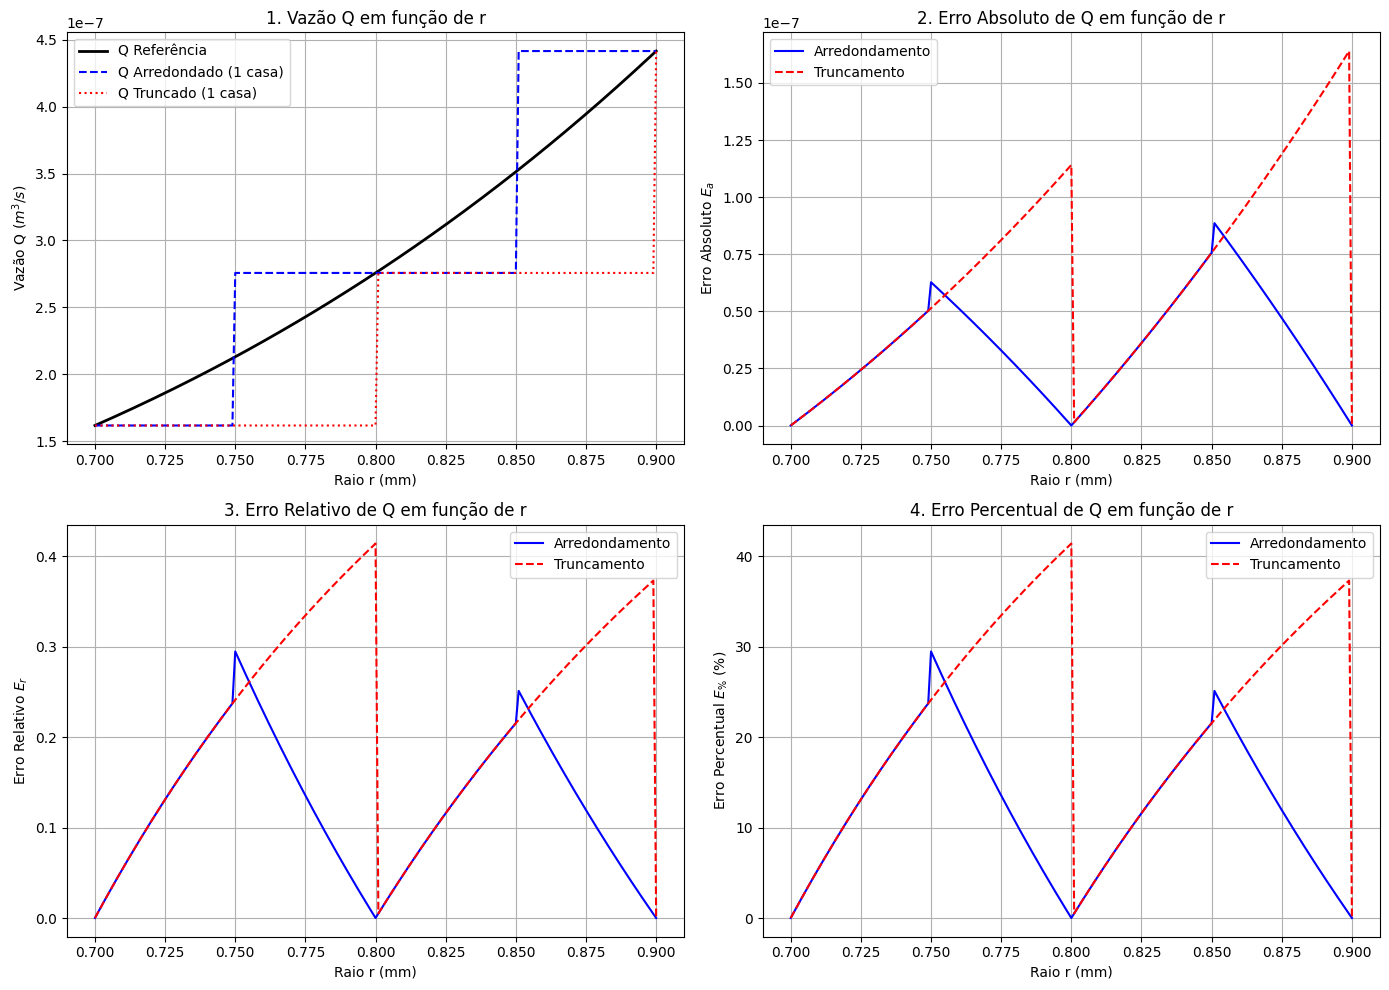

In [101]:
def truncar(x, n):
    return math.trunc(x * (10 ** n)) / (10 ** n)

# Dados fornecidos
L_val = 0.20
mu_orig = 3.5e-3
dp_orig = 1200.0

# Função da vazão Q
def calcula_Q(r_mm, mu=mu_orig, dp=dp_orig, L=L_val):
    r_m = r_mm * 1e-3
    return (np.pi * (r_m ** 4) * dp) / (8 * mu * L)


r_valores = np.linspace(0.70, 0.90, 201)

resultados_r = []

for r in r_valores:
    r_ref = r
    r_arr = round(r, 1)
    r_tru = truncar(r, 1)

    Q_ref = calcula_Q(r_ref)
    Q_arr = calcula_Q(r_arr)
    Q_tru = calcula_Q(r_tru)

    # Erros do Arredondamento
    Ea_arr = abs(Q_ref - Q_arr)
    Er_arr = Ea_arr / Q_ref
    Ep_arr = Er_arr * 100

    # Erros do Truncamento
    Ea_tru = abs(Q_ref - Q_tru)
    Er_tru = Ea_tru / Q_ref
    Ep_tru = Er_tru * 100

    resultados_r.append({
        'r_mm': r,
        'Q_ref': Q_ref,
        'Q_arr': Q_arr, 'Ea_arr': Ea_arr, 'Er_arr': Er_arr, 'Ep_arr': Ep_arr,
        'Q_tru': Q_tru, 'Ea_tru': Ea_tru, 'Er_tru': Er_tru, 'Ep_tru': Ep_tru
    })

df_r = pd.DataFrame(resultados_r)

# Criação dos Gráficos
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# 1. Q em função de r
axs[0, 0].plot(df_r['r_mm'], df_r['Q_ref'], label='Q Referência', color='black', lw=2)
axs[0, 0].plot(df_r['r_mm'], df_r['Q_arr'], label='Q Arredondado (1 casa)', linestyle='--', color='blue')
axs[0, 0].plot(df_r['r_mm'], df_r['Q_tru'], label='Q Truncado (1 casa)', linestyle=':', color='red')
axs[0, 0].set_xlabel('Raio r (mm)')
axs[0, 0].set_ylabel('Vazão Q ($m^3/s$)')
axs[0, 0].set_title('1. Vazão Q em função de r')
axs[0, 0].grid(True)
axs[0, 0].legend()

# 2. Erro Absoluto de Q em função de r
axs[0, 1].plot(df_r['r_mm'], df_r['Ea_arr'], label='Arredondamento', color='blue')
axs[0, 1].plot(df_r['r_mm'], df_r['Ea_tru'], label='Truncamento', color='red', linestyle='--')
axs[0, 1].set_xlabel('Raio r (mm)')
axs[0, 1].set_ylabel('Erro Absoluto $E_a$')
axs[0, 1].set_title('2. Erro Absoluto de Q em função de r')
axs[0, 1].grid(True)
axs[0, 1].legend()

# 3. Erro Relativo de Q em função de r
axs[1, 0].plot(df_r['r_mm'], df_r['Er_arr'], label='Arredondamento', color='blue')
axs[1, 0].plot(df_r['r_mm'], df_r['Er_tru'], label='Truncamento', color='red', linestyle='--')
axs[1, 0].set_xlabel('Raio r (mm)')
axs[1, 0].set_ylabel('Erro Relativo $E_r$')
axs[1, 0].set_title('3. Erro Relativo de Q em função de r')
axs[1, 0].grid(True)
axs[1, 0].legend()

# 4. Erro Percentual de Q em função de r
axs[1, 1].plot(df_r['r_mm'], df_r['Ep_arr'], label='Arredondamento', color='blue')
axs[1, 1].plot(df_r['r_mm'], df_r['Ep_tru'], label='Truncamento', color='red', linestyle='--')
axs[1, 1].set_xlabel('Raio r (mm)')
axs[1, 1].set_ylabel('Erro Percentual $E_\%$ (%)')
axs[1, 1].set_title('4. Erro Percentual de Q em função de r')
axs[1, 1].grid(True)
axs[1, 1].legend()

plt.tight_layout()
plt.show()

# Parte D


# 1)

# 2)

# Parte E

# GIF